# Figure 3: Multi-carcinogen interaction synergy

This notebook regenerates a manuscript-style interaction heatmap from the local
**ExposoGraph** package.

The default figure uses the built-in `smoker_moderate_drinker` profile from
`ExposoGraph.interaction_engine.EXPOSURE_PROFILES`, because it is the package's
representative tobacco-plus-alcohol co-exposure scenario. Pairwise scores are
computed with `compute_interaction_matrix()` and mechanism decomposition is
computed with `decompose_synergy()`.

Important package-alignment notes:

- Scores are pairwise interaction factors, not epidemiologic odds ratios.
- Cells without a modeled pair are shown as `1.00` and flagged in the CSV.
- `Dioxins/PCBs` are modeled in ExposoGraph as AhR/CYP induction modifiers,
  not as a pairwise baseline-risk carcinogen in `compute_interaction_matrix()`.
- `Trichloroethylene/TCE` has CYP2E1 parameters in the interaction JSON, but is
  not currently mapped as a present carcinogen in the public interaction matrix.


In [1]:
from __future__ import annotations

import csv
import sys
from collections import OrderedDict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Make the notebook robust whether it is launched from repo root or Figures_Notebook/.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "ExposoGraph").is_dir() and (candidate / "pyproject.toml").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the ExposoGraph repository root.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

OUTPUT_DIR = REPO_ROOT / "Figures_Notebook" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PROFILE_NAME = "smoker_moderate_drinker"
TISSUE = "Liver"
COLOR_MIN = 1.0
COLOR_MAX = 2.5


## Class mapping

The manuscript labels are mapped to the canonical carcinogen keys used by
`interaction_engine`. Multiple canonical keys may map to a single manuscript
class; the heatmap stores the maximum modeled pairwise synergy for the two
classes in the selected exposure profile.


In [2]:
CLASS_LABELS = [
    "PAHs",
    "Heterocyclic amines",
    "Arylamines",
    "Aflatoxins",
    "Nitrosamines",
    "Benzene",
    "Vinyl chloride",
    "Alcohol(Acetaldehyde)",
    "Formaldehyde",
    "Heavy metals",
    "Dioxins/PCBs",
    "Chlorinated solvents",
    "Estrogens",
    "Aristolochic acid",
]

CANONICAL_TO_CLASS = {
    "PAH": "PAHs",
    "HCA": "Heterocyclic amines",
    "AFB1": "Aflatoxins",
    "NNK": "Nitrosamines",
    "NDMA": "Nitrosamines",
    "benzene": "Benzene",
    "vinyl_chloride": "Vinyl chloride",
    "acetaldehyde": "Alcohol(Acetaldehyde)",
    "formaldehyde": "Formaldehyde",
    "chromium_VI": "Heavy metals",
    "arsenic": "Heavy metals",
    "cadmium": "Heavy metals",
}

CLASS_SUPPORT_NOTES = {
    "Arylamines": "No direct pairwise baseline-risk key in interaction_engine.",
    "Dioxins/PCBs": "Modeled as TCDD/dioxin enzyme induction, not pairwise risk.",
    "Chlorinated solvents": "TCE is not mapped as present carcinogen; vinyl chloride is separate.",
    "Estrogens": "No direct pairwise baseline-risk key in interaction_engine.",
    "Aristolochic acid": "No direct pairwise baseline-risk key in interaction_engine.",
}


## Compute pairwise matrix

For each canonical pair in the selected ExposoGraph profile, the notebook:

1. runs the full interaction matrix,
2. decomposes synergy into competition, GSH, induction, and residual terms,
3. maps canonical carcinogens to manuscript classes,
4. stores the strongest modeled canonical pair for each class-pair cell.


In [3]:
from ExposoGraph.interaction_engine import (
    EXPOSURE_PROFILES,
    compute_interaction_matrix,
    decompose_synergy,
)

profile = EXPOSURE_PROFILES[PROFILE_NAME]
result = compute_interaction_matrix(
    profile["exposure"],
    lifestyle=profile.get("lifestyle", {}),
    genotypes=profile.get("genotypes", {}),
    tissue=TISSUE,
)
decomposition = decompose_synergy(
    profile["exposure"],
    lifestyle=profile.get("lifestyle", {}),
    genotypes=profile.get("genotypes", {}),
    tissue=TISSUE,
)

label_index = {label: idx for idx, label in enumerate(CLASS_LABELS)}
matrix = np.ones((len(CLASS_LABELS), len(CLASS_LABELS)), dtype=float)
support = np.full((len(CLASS_LABELS), len(CLASS_LABELS)), "not_modeled", dtype=object)
source_pair = np.full((len(CLASS_LABELS), len(CLASS_LABELS)), "", dtype=object)
dominant_mechanism = np.full((len(CLASS_LABELS), len(CLASS_LABELS)), "", dtype=object)

for idx in range(len(CLASS_LABELS)):
    matrix[idx, idx] = np.nan
    support[idx, idx] = "diagonal"


def dominant_from_decomposition(pair_name: str) -> str:
    dec = decomposition.get(pair_name)
    if dec is None:
        return "not_decomposed"
    terms = {
        "competitive inhibition": dec.delta_comp,
        "GSH depletion": dec.delta_gsh,
        "enzyme induction": dec.delta_ind,
        "residual": dec.residual,
    }
    positive_terms = {key: value for key, value in terms.items() if value > 0}
    if positive_terms:
        return max(positive_terms, key=positive_terms.get)
    if dec.delta_comp < 0:
        return "competitive antagonism"
    return "near-additive"


for pair_name, score in result.synergy_matrix.items():
    left, right = pair_name.split("_x_")
    left_class = CANONICAL_TO_CLASS.get(left)
    right_class = CANONICAL_TO_CLASS.get(right)
    if left_class is None or right_class is None or left_class == right_class:
        continue

    i = label_index[left_class]
    j = label_index[right_class]
    if score > matrix[i, j]:
        for row, col in [(i, j), (j, i)]:
            matrix[row, col] = float(score)
            support[row, col] = "computed"
            source_pair[row, col] = pair_name
            dominant_mechanism[row, col] = dominant_from_decomposition(pair_name)

for label, note in CLASS_SUPPORT_NOTES.items():
    idx = label_index[label]
    for j in range(len(CLASS_LABELS)):
        if idx != j and support[idx, j] == "not_modeled":
            support[idx, j] = note
            support[j, idx] = note if support[j, idx] == "not_modeled" else support[j, idx]

print(f"Profile: {PROFILE_NAME}")
print(f"Overall interaction factor: {result.interaction_factor}")
print(f"Total independent risk: {result.total_independent_risk}")
print(f"Total interaction-adjusted risk: {result.total_interaction_risk}")
print(f"GSH fraction normal: {result.gsh_status.fraction_normal}")
print(f"Active inducers: {', '.join(result.induction_effects.active_inducers)}")


Profile: smoker_moderate_drinker
Overall interaction factor: 1.7006
Total independent risk: 498.9
Total interaction-adjusted risk: 848.406
GSH fraction normal: 0.877
Active inducers: alcohol_moderate, smoking


In [4]:
# Save matrix and long-form audit tables.
matrix_csv = OUTPUT_DIR / "figure3_interaction_synergy_matrix.csv"
long_csv = OUTPUT_DIR / "figure3_interaction_synergy_decomposition_long.csv"

with matrix_csv.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.writer(handle)
    writer.writerow(["carcinogen_class", *CLASS_LABELS])
    for label, row in zip(CLASS_LABELS, matrix):
        values = ["" if np.isnan(value) else round(float(value), 3) for value in row]
        writer.writerow([label, *values])

with long_csv.open("w", newline="", encoding="utf-8") as handle:
    fieldnames = [
        "row_class",
        "column_class",
        "score",
        "source_canonical_pair",
        "support",
        "dominant_mechanism",
        "delta_comp",
        "delta_gsh",
        "delta_ind",
        "residual",
    ]
    writer = csv.DictWriter(handle, fieldnames=fieldnames)
    writer.writeheader()
    for i, row_class in enumerate(CLASS_LABELS):
        for j, column_class in enumerate(CLASS_LABELS):
            if j <= i:
                continue
            pair = str(source_pair[i, j])
            dec = decomposition.get(pair)
            writer.writerow({
                "row_class": row_class,
                "column_class": column_class,
                "score": "" if np.isnan(matrix[i, j]) else round(float(matrix[i, j]), 4),
                "source_canonical_pair": pair,
                "support": support[i, j],
                "dominant_mechanism": dominant_mechanism[i, j],
                "delta_comp": "" if dec is None else dec.delta_comp,
                "delta_gsh": "" if dec is None else dec.delta_gsh,
                "delta_ind": "" if dec is None else dec.delta_ind,
                "residual": "" if dec is None else dec.residual,
            })

print(matrix_csv)
print(long_csv)


/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure3_interaction_synergy_matrix.csv
/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure3_interaction_synergy_decomposition_long.csv


## Render heatmap

The color range is capped at 2.5 so the visual scale remains comparable to the
draft manuscript figure. Values above this cap retain their true numeric
annotation but use the maximum color.


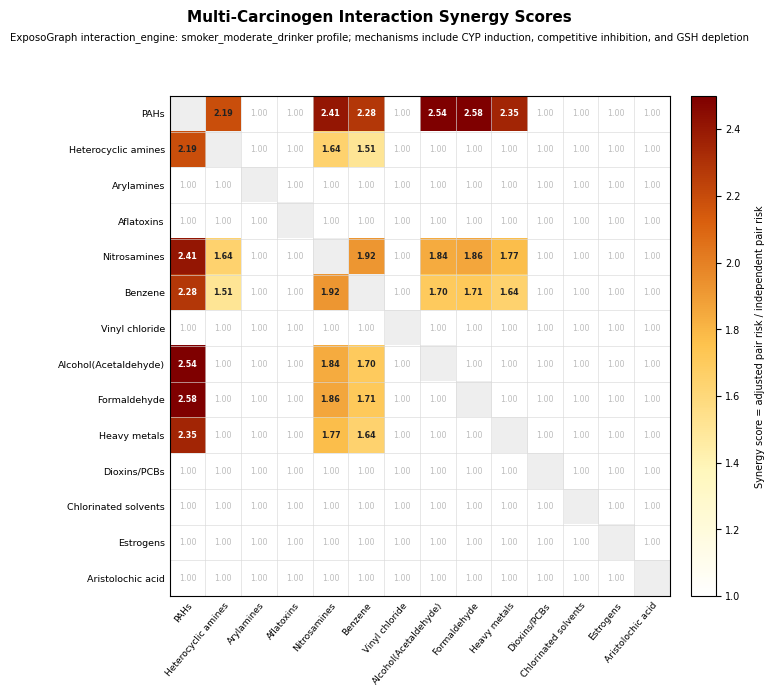

/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure3_multicarcinogen_interaction_synergy.png
/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure3_multicarcinogen_interaction_synergy.pdf
/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure3_multicarcinogen_interaction_synergy.svg


In [5]:
display_matrix = np.clip(matrix, COLOR_MIN, COLOR_MAX)
masked_matrix = np.ma.masked_invalid(display_matrix)

cmap = LinearSegmentedColormap.from_list(
    "exposograph_synergy",
    ["#ffffff", "#fff7bc", "#fec44f", "#d95f0e", "#7f0000"],
)
cmap.set_bad("#eeeeee")

fig, ax = plt.subplots(figsize=(9.4, 8.2), constrained_layout=False)
fig.subplots_adjust(left=0.23, right=0.86, bottom=0.25, top=0.86)
im = ax.imshow(masked_matrix, cmap=cmap, vmin=COLOR_MIN, vmax=COLOR_MAX)

ax.set_xticks(np.arange(len(CLASS_LABELS)))
ax.set_yticks(np.arange(len(CLASS_LABELS)))
ax.set_xticklabels(CLASS_LABELS, rotation=50, ha="right", rotation_mode="anchor", fontsize=6.6)
ax.set_yticklabels(CLASS_LABELS, fontsize=6.8)

ax.set_xticks(np.arange(-0.5, len(CLASS_LABELS), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(CLASS_LABELS), 1), minor=True)
ax.grid(which="minor", color="#d9d9d9", linestyle="-", linewidth=0.45)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", length=0)

for i in range(len(CLASS_LABELS)):
    for j in range(len(CLASS_LABELS)):
        value = matrix[i, j]
        if np.isnan(value):
            continue
        if value >= 1.2:
            label = f"{value:.2f}"
            color = "white" if value >= 2.25 else "#222222"
            weight = "bold"
        else:
            label = "1.00"
            color = "#bdbdbd"
            weight = "normal"
        ax.text(j, i, label, ha="center", va="center", fontsize=5.8, color=color, weight=weight)

fig.suptitle(
    "Multi-Carcinogen Interaction Synergy Scores",
    fontsize=11,
    weight="bold",
    y=0.965,
)
fig.text(
    0.5,
    0.925,
    "ExposoGraph interaction_engine: smoker_moderate_drinker profile; "
    "mechanisms include CYP induction, competitive inhibition, and GSH depletion",
    ha="center",
    va="bottom",
    fontsize=7.3,
)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.035)
cbar.set_label(
    "Synergy score = adjusted pair risk / independent pair risk",
    rotation=90,
    labelpad=10,
    fontsize=7,
)
cbar.ax.tick_params(labelsize=7)
'''
fig.text(
    0.23,
    0.035,
    "Data source: ExposoGraph.interaction_engine.compute_interaction_matrix() "
    "and decompose_synergy().\n"
    "Cells with no modeled pairwise interaction are shown as 1.00; "
    "see CSV support column.\n"
    "Dioxins/PCBs are modeled as TCDD/dioxin induction modifiers, "
    "not pairwise baseline-risk carcinogens.",
    fontsize=5.8,
    ha="left",
    va="bottom",
    color="#555555",
)
'''
png_path = OUTPUT_DIR / "figure3_multicarcinogen_interaction_synergy.png"
pdf_path = OUTPUT_DIR / "figure3_multicarcinogen_interaction_synergy.pdf"
svg_path = OUTPUT_DIR / "figure3_multicarcinogen_interaction_synergy.svg"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(svg_path, bbox_inches="tight")
plt.show()

print(png_path)
print(pdf_path)
print(svg_path)


## Top modeled class pairs


In [6]:
top_pairs = []
for i, row_class in enumerate(CLASS_LABELS):
    for j, column_class in enumerate(CLASS_LABELS):
        if j <= i:
            continue
        value = matrix[i, j]
        if not np.isnan(value) and value > 1.0:
            top_pairs.append(
                (value, row_class, column_class, source_pair[i, j], dominant_mechanism[i, j])
            )

for value, row_class, column_class, pair, mechanism in sorted(top_pairs, reverse=True)[:12]:
    print(f"{row_class} x {column_class}: {value:.3f} ({pair}; dominant: {mechanism})")


PAHs x Formaldehyde: 2.579 (PAH_x_formaldehyde; dominant: enzyme induction)
PAHs x Alcohol(Acetaldehyde): 2.538 (PAH_x_acetaldehyde; dominant: enzyme induction)
PAHs x Nitrosamines: 2.410 (PAH_x_NDMA; dominant: enzyme induction)
PAHs x Heavy metals: 2.351 (PAH_x_cadmium; dominant: enzyme induction)
PAHs x Benzene: 2.281 (PAH_x_benzene; dominant: enzyme induction)
PAHs x Heterocyclic amines: 2.187 (PAH_x_HCA; dominant: enzyme induction)
Nitrosamines x Benzene: 1.916 (NNK_x_benzene; dominant: enzyme induction)
Nitrosamines x Formaldehyde: 1.857 (NNK_x_formaldehyde; dominant: enzyme induction)
Nitrosamines x Alcohol(Acetaldehyde): 1.842 (NNK_x_acetaldehyde; dominant: enzyme induction)
Nitrosamines x Heavy metals: 1.769 (NNK_x_cadmium; dominant: enzyme induction)
Benzene x Formaldehyde: 1.713 (benzene_x_formaldehyde; dominant: enzyme induction)
Benzene x Alcohol(Acetaldehyde): 1.700 (benzene_x_acetaldehyde; dominant: enzyme induction)
